# Diabetes Prediction Analysis

## Objective

Predict whether a patient has diabetes based on medical measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working!")

Everything is working!


# Phase 1: Data Cleaning & Preprocessing

In [2]:
df = pd.read_csv(r"C:\Users\marti\OneDrive\Desktop\Diabetes-Prediction\data\diabetes.csv")
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [3]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

(df[columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

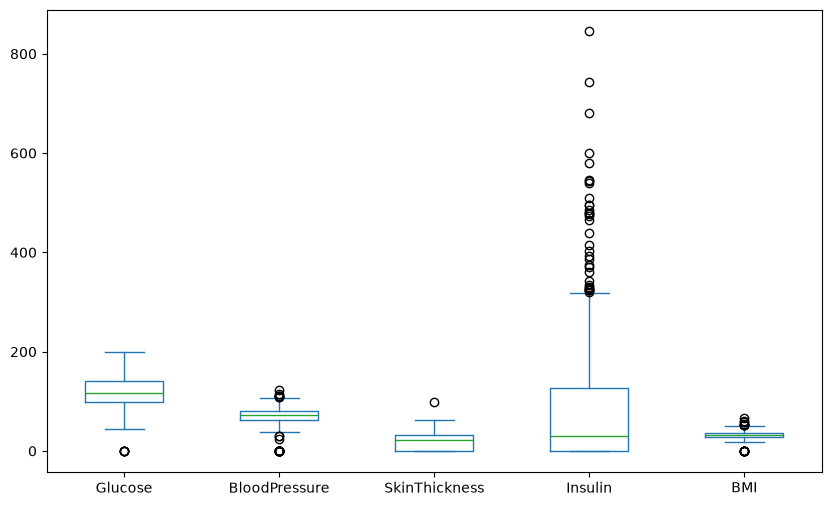

In [7]:
import matplotlib.pyplot as plt

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns].plot(kind="box", figsize=(10,6))
plt.show()

In [8]:
df[(df[columns] == 0).sum(axis=1) >= 4]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
706,10,115,0,0,0,0.0,0.261,30,1


In [9]:
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df = df[(df[columns] == 0).sum(axis=1) < 4]

In [10]:
df[(df[columns] == 0).sum(axis=1) >= 4]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


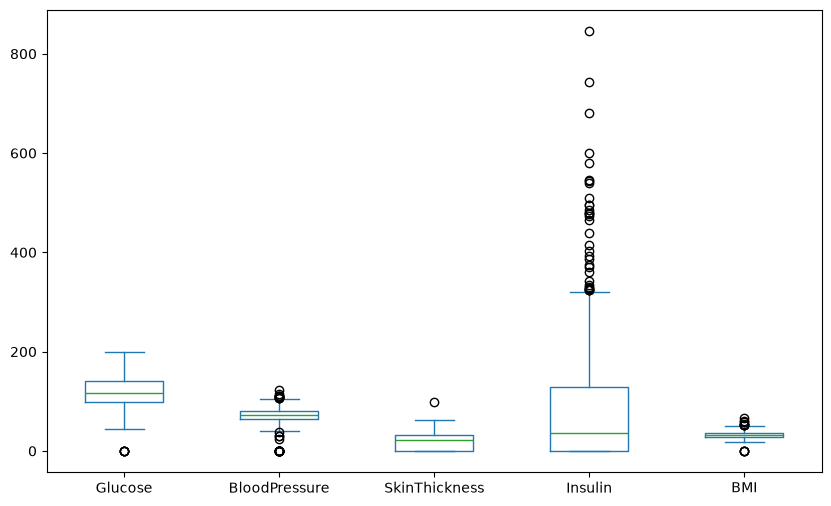

In [11]:
import matplotlib.pyplot as plt

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns].plot(kind="box", figsize=(10,6))
plt.show()

In [12]:
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns:
    median = df.loc[df[col] != 0, col].median()
    df[col] = df[col].replace(0, median)

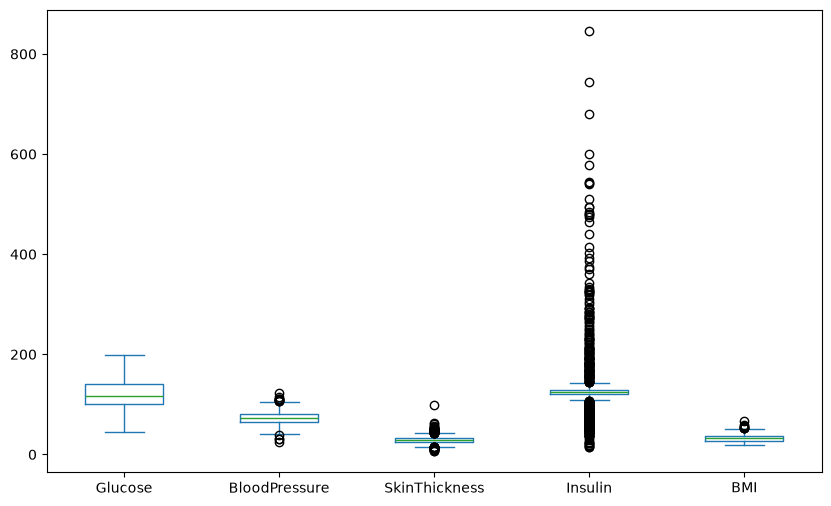

In [13]:
import matplotlib.pyplot as plt

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns].plot(kind="box", figsize=(10,6))
plt.show()

# Phase 02: Exploratory Data Analysis (EDA)

In [14]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    64.914586
1    35.085414
Name: proportion, dtype: float64

## Glucose vs Outcome

<Axes: xlabel='Outcome', ylabel='Glucose'>

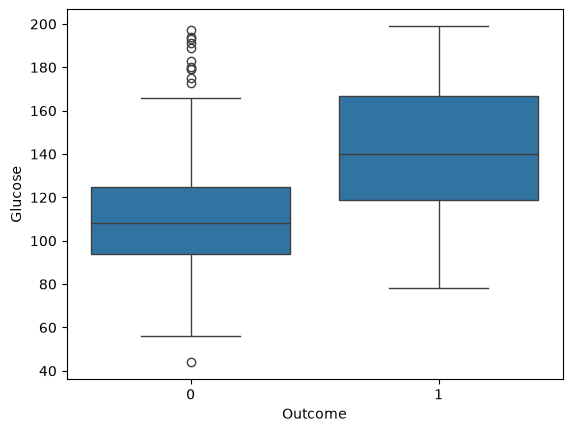

In [15]:
sns.boxplot(x="Outcome", y="Glucose", data=df)

## BMI vs Outcome

<Axes: xlabel='Outcome', ylabel='BMI'>

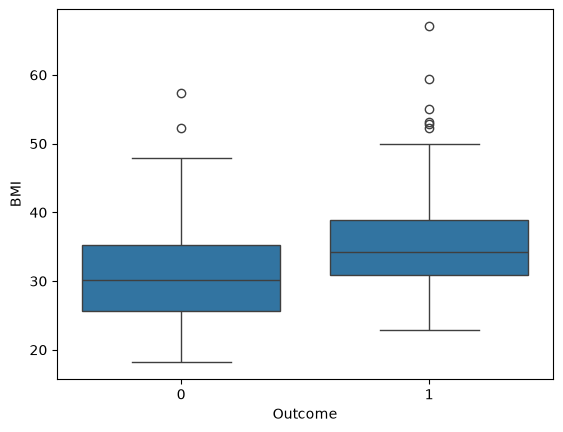

In [16]:
sns.boxplot(x="Outcome", y="BMI", data=df)

## Age vs Outcome

<Axes: xlabel='Outcome', ylabel='Age'>

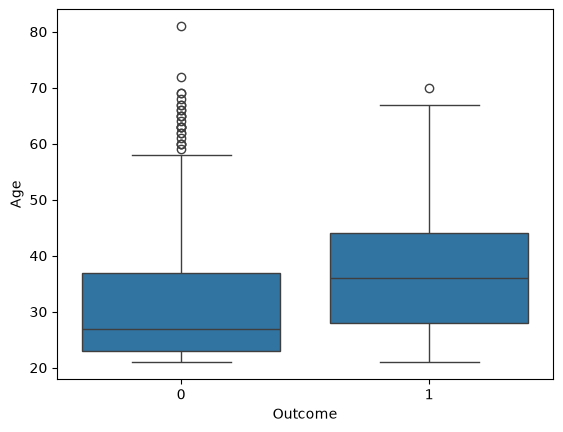

In [17]:
sns.boxplot(x="Outcome", y="Age", data=df)

## Insulin vs Outcome

<Axes: xlabel='Outcome', ylabel='Insulin'>

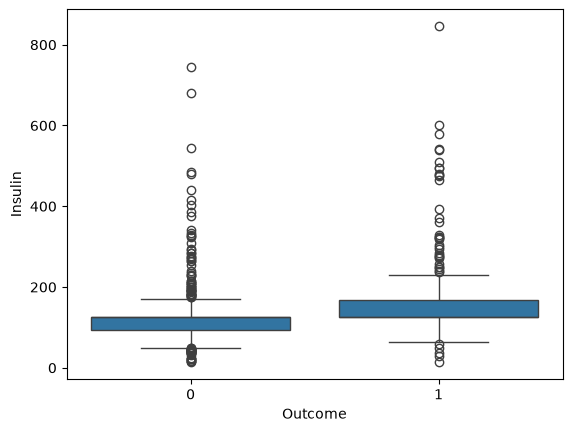

In [18]:
sns.boxplot(x="Outcome", y="Insulin", data=df)

## BloodPressure vs Outcome

<Axes: xlabel='Outcome', ylabel='BloodPressure'>

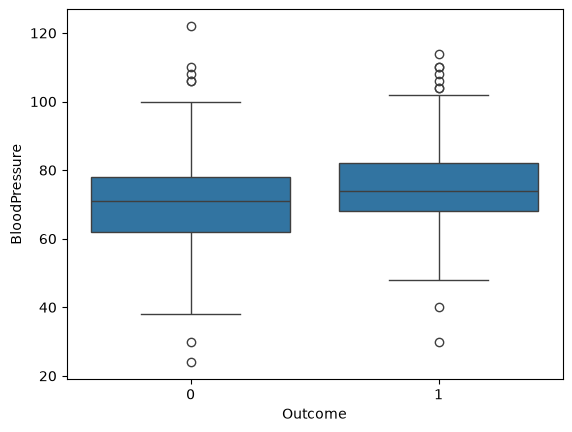

In [19]:
sns.boxplot(x="Outcome", y="BloodPressure", data=df)

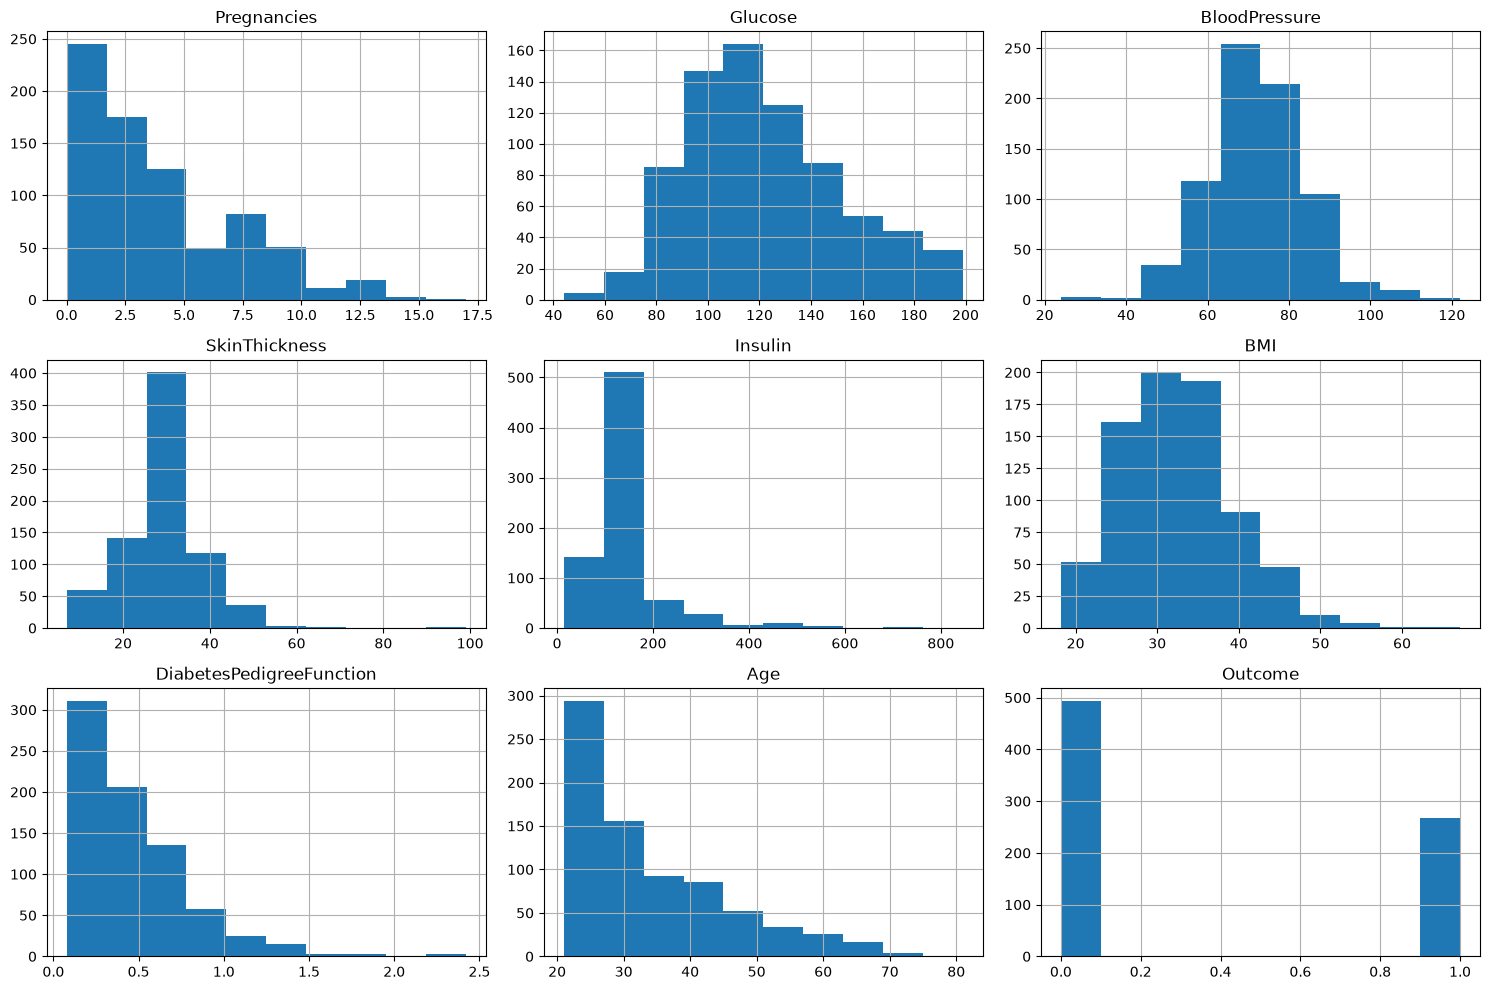

In [20]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## The strongest feature associated with diabetes

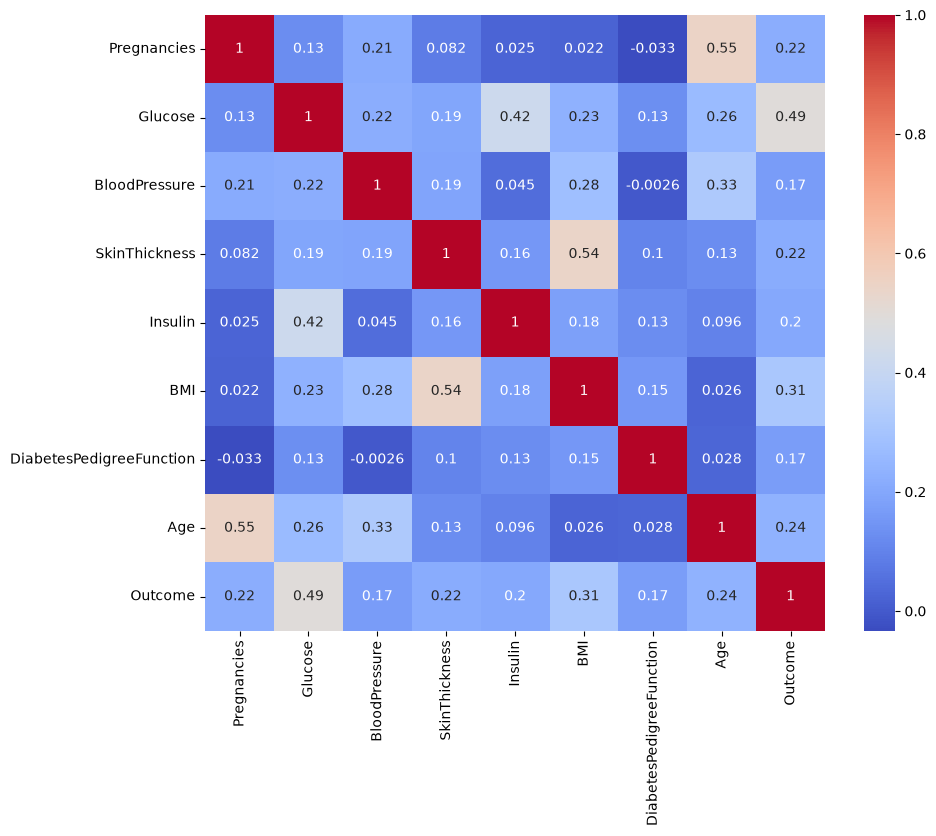

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [22]:
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.297571,110.910931,70.906883,27.710526,127.825911,30.868421,0.432261,31.285425
1,4.846442,142.232210,75.134831,31.696629,164.850187,35.395131,0.551584,37.093633


## Which feature is most distinguishing between those who are infected and those who are not?

In [23]:
comparison = df.groupby("Outcome").mean().T

comparison["Difference"] = (
    comparison[1] - comparison[0]
).abs()

comparison.sort_values("Difference", ascending=False)

Outcome,0,1,Difference
Insulin,127.825911,164.850187,37.024276
Glucose,110.910931,142.232210,31.321279
Age,31.285425,37.093633,5.808208
BMI,30.868421,35.395131,4.526710
BloodPressure,70.906883,75.134831,4.227949
SkinThickness,27.710526,31.696629,3.986103
Pregnancies,3.297571,4.846442,1.548871
DiabetesPedigreeFunction,0.432261,0.551584,0.119323


# Phase 3: ML
## No additional feature engineering is required.
### The dataset already contains meaningful medical features.

### 3.1 Feature Selection

In [24]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [25]:
print(X.head())

print(y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


### 3.3 Train-Test Split

In [26]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(608, 8)
(153, 8)
(608,)
(153,)


### 3.4 Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [31]:
print(X_train[:5])

[[ 0.03470896  0.83846959  0.1707794  -0.4669074   1.71293627  0.35709801
  -0.28316842 -0.29198827]
 [-0.55148678  0.80517612  0.00317024 -0.02108141 -0.18903523 -0.74766398
  -0.7123118  -0.45954736]
 [ 0.03470896  0.40565456  0.00317024 -0.02108141 -0.18903523 -1.30004498
  -0.60280625  2.22139822]
 [-1.13768251 -1.2590186  -0.6672664  -0.8012769  -0.85698951  0.49146096
   0.19036909 -1.04600421]
 [ 2.37949189 -0.02716046  0.50599772 -1.35855939 -0.18903523 -0.89695614
  -0.65607922  2.38895732]]


### 3.5 Model Training

In [33]:
from sklearn.linear_model import LogisticRegression

In [35]:
model = LogisticRegression()

In [37]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### 3.6 Prediction

In [43]:
y_pred = model.predict(X_test)
print(y_test[:10].values)
print(y_pred[:10])

[1 0 1 1 0 0 1 0 1 0]
[1 1 1 1 0 0 0 0 1 0]


### 3.7 Model Evaluation

In [45]:
from sklearn.metrics import accuracy_score

In [46]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8235294117647058


In [47]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 82.35%


#### 3.7.2 Confusion Matrix

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[92 10]
 [17 34]]


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       102
           1       0.77      0.67      0.72        51

    accuracy                           0.82       153
   macro avg       0.81      0.78      0.79       153
weighted avg       0.82      0.82      0.82       153



### 3.8 Model Comparison

In [58]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, tree_pred)

print(tree_accuracy)

0.7777777777777778


In [60]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.63      0.78      0.70        51

    accuracy                           0.78       153
   macro avg       0.76      0.78      0.76       153
weighted avg       0.80      0.78      0.78       153



In [61]:
print(confusion_matrix(y_test, tree_pred))

[[79 23]
 [11 40]]
